# 03 — Ground Data: First Supervised Models (v0)

## Purpose
This notebook builds the first supervised forecasting models using ground data only.
The goal is to beat a persistence baseline at a fixed forecast horizon using simple,
fast, and reliable models (linear regularized regression).

**Inputs**
- data/ground_aligned/ground_10min_utc_uniandes.parquet
- data/ground_aligned/ground_10min_utc_elpaso.parquet

## Imports and settings

In [3]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ! pip install scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ground_aligned"

UNI_PATH = DATA_DIR / "ground_10min_utc_uniandes.parquet"
ELP_PATH = DATA_DIR / "ground_10min_utc_elpaso.parquet"

print("UNI exists:", UNI_PATH.exists(), "->", UNI_PATH)
print("ELP exists:", ELP_PATH.exists(), "->", ELP_PATH)

UNI exists: True -> /srv/projects/Proyecto_e_ladino/data/ground_aligned/ground_10min_utc_uniandes.parquet
ELP exists: True -> /srv/projects/Proyecto_e_ladino/data/ground_aligned/ground_10min_utc_elpaso.parquet


## Loading datasets

In [4]:
uni = pd.read_parquet(UNI_PATH)
elp = pd.read_parquet(ELP_PATH)

print("UNI shape:", uni.shape, "| tz:", uni.index.tz)
print("ELP shape:", elp.shape, "| tz:", elp.index.tz)

assert "ghi" in uni.columns, "UNI missing 'ghi'"
assert "ghi" in elp.columns, "ELP missing 'ghi'"
assert str(uni.index.tz) == "UTC", "UNI index is not UTC"
assert str(elp.index.tz) == "UTC", "ELP index is not UTC"

display(uni.head(3))
display(elp.head(3))

UNI shape: (82657, 6) | tz: UTC
ELP shape: (107172, 9) | tz: UTC


,relative_humidity_pct,air_pressure_hpa,wind_direction_deg,ghi,air_temperature_c,wind_speed_ms
2023-09-01 05:00:00+00:00,73.896,745.288,163.000,0.0,12.718,1.042
2023-09-01 05:10:00+00:00,76.484,745.140,113.694,0.0,11.932,2.728
2023-09-01 05:20:00+00:00,75.824,744.972,116.006,0.0,12.318,1.346


,clear_sky_index,ghi,air_pressure_hpa,air_temperature_c,wind_y,wind_x,doy_sin,doy_cos,hour_of_day
2022-02-21 18:00:00+00:00,2.0,3.0352,1000.7912,29.9672,2.832954,-0.093612,0.778764,0.627317,18
2022-02-21 18:10:00+00:00,0.0,0.3562,1000.9321,29.5689,3.387552,0.796801,0.778764,0.627317,18
2022-02-21 18:20:00+00:00,0.0,0.0000,1001.1479,29.2593,2.091197,-0.878680,0.778764,0.627317,18


## Temporal splits
copied from Notebook 02

In [5]:
SPLITS = {
    "uniandes": {
        "train": ("2023-09-01", "2024-09-30"),
        "val":   ("2024-10-01", "2024-12-31"),
        "test":  ("2025-01-01", "2025-03-28"),
    },
    "elpaso": {
        "train": ("2022-03-01", "2023-06-30"),
        "val":   ("2023-07-01", "2023-10-31"),
        "test":  ("2023-11-01", "2024-03-07"),
    },
}

In [6]:
def slice_by_date(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC")
    return df.loc[(df.index >= start_ts) & (df.index < end_ts)].copy()

def build_splits(df: pd.DataFrame, site_key: str) -> dict[str, pd.DataFrame]:
    spec = SPLITS[site_key]
    return {name: slice_by_date(df, s, e) for name, (s, e) in spec.items()}

uni_splits = build_splits(uni, "uniandes")
elp_splits = build_splits(elp, "elpaso")

for k, v in uni_splits.items():
    print("UNI", k, v.index.min(), "→", v.index.max(), "| rows:", len(v))
for k, v in elp_splits.items():
    print("ELP", k, v.index.min(), "→", v.index.max(), "| rows:", len(v))

UNI train 2023-09-01 05:00:00+00:00 → 2024-09-29 23:50:00+00:00 | rows: 56850
UNI val 2024-10-01 00:00:00+00:00 → 2024-12-30 23:50:00+00:00 | rows: 13104
UNI test 2025-01-01 00:00:00+00:00 → 2025-03-27 23:50:00+00:00 | rows: 12384
ELP train 2022-03-01 00:00:00+00:00 → 2023-06-29 23:50:00+00:00 | rows: 69984
ELP val 2023-07-01 00:00:00+00:00 → 2023-10-30 23:50:00+00:00 | rows: 17568
ELP test 2023-11-01 00:00:00+00:00 → 2024-03-06 23:50:00+00:00 | rows: 18288


## Forecast horizon definition
- The forecast horizon is defined in discrete steps on a 10-minute grid.
- Here I use a 6-hour horizon, equivalent to 36 steps.

In [7]:
FREQ_MIN = 10
HOURS_AHEAD = 6
H = int((HOURS_AHEAD * 60) / FREQ_MIN)

print("Forecast horizon:", HOURS_AHEAD, "hours")
print("Horizon steps:", H)

Forecast horizon: 6 hours
Horizon steps: 36


## Supervised dataset construction

The supervised target was defined as: $y(t) = ghi(t + H)$

In [8]:
def make_supervised(df: pd.DataFrame, horizon_steps: int) -> pd.DataFrame:
    out = df.copy()
    out["y"] = out["ghi"].shift(-horizon_steps)
    out = out.dropna(subset=["ghi", "y"])
    return out

uni_sup = {k: make_supervised(v, H) for k, v in uni_splits.items()}
elp_sup = {k: make_supervised(v, H) for k, v in elp_splits.items()}

for split_name in ["train", "val", "test"]:
    print("UNI", split_name, "rows:", len(uni_sup[split_name]))
    print("ELP", split_name, "rows:", len(elp_sup[split_name]))

UNI train rows: 56693
ELP train rows: 69948
UNI val rows: 13066
ELP val rows: 17532
UNI test rows: 12348
ELP test rows: 18252


## Feature selection

In [9]:
def select_features(df: pd.DataFrame) -> list[str]:
    feats = []
    for c in df.columns:
        if c == "y":
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            feats.append(c)
    if "ghi" not in feats:
        feats.append("ghi")
    return sorted(set(feats))

uni_feats = select_features(uni_sup["train"])
elp_feats = select_features(elp_sup["train"])

print("UNI features:", uni_feats)
print("ELP features:", elp_feats)

UNI features: ['air_pressure_hpa', 'air_temperature_c', 'ghi', 'relative_humidity_pct', 'wind_direction_deg', 'wind_speed_ms']
ELP features: ['air_pressure_hpa', 'air_temperature_c', 'clear_sky_index', 'doy_cos', 'doy_sin', 'ghi', 'hour_of_day', 'wind_x', 'wind_y']


## Baseline: Persistance

Persistance: $\hat{y}(t) = ghi(t)$

In [10]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def eval_persistence(df_sup: pd.DataFrame) -> dict:
    y_true = df_sup["y"].to_numpy()
    y_pred = df_sup["ghi"].to_numpy()
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }

uni_base = eval_persistence(uni_sup["test"])
elp_base = eval_persistence(elp_sup["test"])

print("UNI persistence (test):", uni_base)
print("ELP persistence (test):", elp_base)

UNI persistence (test): {'rmse': 389.5664355256399, 'mae': 251.48144039520568}
ELP persistence (test): {'rmse': 496.89016564247976, 'mae': 368.02757560267366}


## Model

### Ridge regression

In [11]:
def fit_ridge_v0(site: str, sup: dict[str, pd.DataFrame], feat_cols: list[str]) -> tuple[dict, np.ndarray, np.ndarray]:
    Xtr = sup["train"][feat_cols].to_numpy()
    ytr = sup["train"]["y"].to_numpy()

    Xva = sup["val"][feat_cols].to_numpy()
    yva = sup["val"]["y"].to_numpy()

    Xte = sup["test"][feat_cols].to_numpy()
    yte = sup["test"]["y"].to_numpy()

    alphas = [0.1, 1.0, 10.0, 100.0]
    best_alpha = None
    best_val_rmse = None
    best_model = None

    for a in alphas:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("reg", Ridge(alpha=a, random_state=42)),
        ])
        model.fit(Xtr, ytr)

        yhat_va = model.predict(Xva)
        val_rmse = rmse(yva, yhat_va)

        if (best_val_rmse is None) or (val_rmse < best_val_rmse):
            best_val_rmse = val_rmse
            best_alpha = a
            best_model = model

    yhat_te = best_model.predict(Xte)

    out = {
        "site": site,
        "model": "Ridge",
        "alpha": best_alpha,
        "val_rmse": float(best_val_rmse),
        "test_rmse": rmse(yte, yhat_te),
        "test_mae": float(mean_absolute_error(yte, yhat_te)),
    }

    return out, yte, yhat_te

uni_out, uni_yte, uni_yhat = fit_ridge_v0("uniandes", uni_sup, uni_feats)
elp_out, elp_yte, elp_yhat = fit_ridge_v0("elpaso", elp_sup, elp_feats)

results = pd.DataFrame([uni_out, elp_out])
display(results)

,site,model,alpha,val_rmse,test_rmse,test_mae
0,uniandes,Ridge,100.0,225.885320,229.298493,179.762339
1,elpaso,Ridge,0.1,226.966555,216.461546,158.952861


## Skill vs persistance

$$skill = 1 - \frac{RMSE_{model}}{RMSE_{persistence}}$$

In [12]:
def skill_vs_persistence(y_true: np.ndarray, y_pred: np.ndarray, y_persist: np.ndarray) -> float:
    rmse_m = rmse(y_true, y_pred)
    rmse_b = rmse(y_true, y_persist)
    return float(1.0 - rmse_m / (rmse_b + 1e-12))

results["test_skill_vs_persistence"] = [
    skill_vs_persistence(uni_yte, uni_yhat, uni_sup["test"]["ghi"].to_numpy()),
    skill_vs_persistence(elp_yte, elp_yhat, elp_sup["test"]["ghi"].to_numpy()),
]
display(results)

,site,model,alpha,val_rmse,test_rmse,test_mae,test_skill_vs_persistence
0,uniandes,Ridge,100.0,225.885320,229.298493,179.762339,0.411401
1,elpaso,Ridge,0.1,226.966555,216.461546,158.952861,0.564367


## Qualitative check

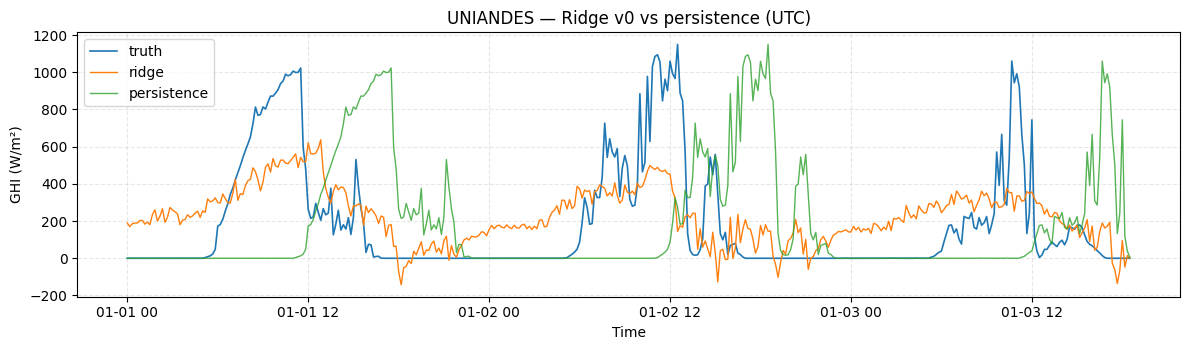

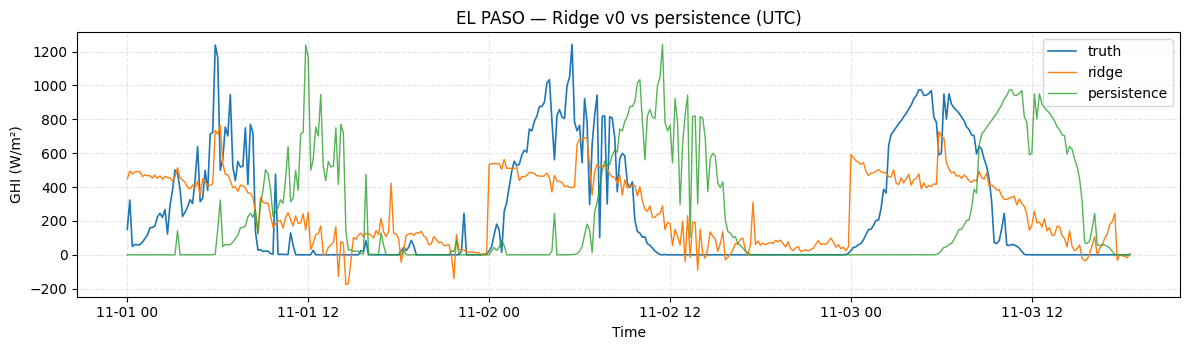

In [13]:
def plot_window(df_sup: pd.DataFrame, y_pred: np.ndarray, title: str, n: int = 400):
    y_true = df_sup["y"].to_numpy()[:n]
    y_pers = df_sup["ghi"].to_numpy()[:n]
    idx = df_sup.index[:n]

    plt.figure(figsize=(12, 3.6))
    plt.plot(idx, y_true, label="truth", linewidth=1.2)
    plt.plot(idx, y_pred[:n], label="ridge", linewidth=1.0)
    plt.plot(idx, y_pers, label="persistence", linewidth=1.0, alpha=0.8)
    plt.title(title + " (UTC)")
    plt.xlabel("Time")
    plt.ylabel("GHI (W/m²)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_window(uni_sup["test"], uni_yhat, "UNIANDES — Ridge v0 vs persistence")
plot_window(elp_sup["test"], elp_yhat, "EL PASO — Ridge v0 vs persistence")

## Export

In [16]:
OUT_DIR = PROJECT_ROOT / "runs" / "ground_models_v0"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / f"ridge_v0_H{HOURS_AHEAD}h.parquet"
results.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: /srv/projects/Proyecto_e_ladino/runs/ground_models_v0/ridge_v0_H6h.parquet
